# L1 — Créer un premier agent avec LangChain et Mistral

<img src="./assets/LC_L1_Top.png" align="left" width="500">

## Objectifs pédagogiques

À la fin de cette leçon, vous serez capable de :

- Comprendre ce qu'est un **agent IA** et comment il fonctionne
- Construire un premier agent avec `create_agent` de LangChain
- Connecter l'agent au modèle **Mistral AI**
- Donner à l'agent accès à une base de données via un `tool`
- Interroger cet agent en langage naturel

---

```text
Utilisateur (question en français) → Agent LangChain → Modèle Mistral → Tool : execute_sql → Base SQLite (Chinook) → Réponse en langage naturel
```

## 1. Qu'est-ce qu'un agent IA ?

### Objectif

Comprendre le concept d'agent.

### Méthode

Un **agent IA** est un programme capable de :
1. Recevoir une question en langage naturel
2. Décider quelle action effectuer (appeler un outil, répondre directement...)
3. Exécuter cette action
4. Observer le résultat
5. Recommencer si nécessaire
6. Formuler une réponse finale

C'est le **modèle Mistral** qui prend les décisions. **LangChain** orchestre le tout.

### Résultat attendu

Vous comprendrez pourquoi un agent est différent d'un simple appel LLM.

---

Imaginons une analogie simple :

> Un **agent** ressemble à un assistant intelligent qui a accès à des outils.
> Si vous lui demandez *"Quel est le chiffre d'affaires de ce mois ?"*, il ne répond pas de mémoire.
> Il **ouvre la base de données**, **exécute une requête SQL**, **lit le résultat**, puis vous répond.

```text
Agent
 ├── Décision : ai-je besoin d'un outil ?
 ├── OUI → appel outil → résultat → réponse finale
 └── NON → réponse directe
```

## 2. Préparer l'environnement

### Objectif

1. Créer votre `.venv` et installer les bibliothèques nécessaires à la formation.
2. Charger la clé API Mistral et initialiser le modèle.

### Méthode

1. Ouvrez votre projet github (dossier) via VS Code (Solution recommendée)
2. Disponiliser l'**Environnement virtuel** depuis le dossier `~multiagent-mistral-langchain/` (nom du projet)
3. Sélectionner le kernel `.venv` dans VSCode (bouton **"Select Kernel"** en haut à droite).
4. Récupérer votre **Clé API** puis ajoutez là à votre `.env` (utilisez directement le fichier d'exemple`example_mistral.env`). ⚠️ La clé API ne doit **jamais** être écrite directement dans le code, le .env doit être exlu via votre `.gitignore` ⚠️
5. Utiliser `python-dotenv` pour charger les variables depuis ce fichier `.env`.

### Résultat attendu

- Le `.venv` est actif et toutes les bibliothèques sont disponibles.
- La clé `MISTRAL_API_KEY` est chargée et le modèle Mistral peut être initialisé.

### 2.1. Prérequis

Déplacer (copier/coller, ou cloner) le projet GitHub dans `C:\Users\[USER_NAME]\multiagent-mistral-langchain`. Attention, veillier à ne pas mettre ce fichier dans un dossier One Drive ou tout autre dossier herbergé dans le Cloud.

- **Python 3.11+**
- **[uv](https://docs.astral.sh/uv/getting-started/installation/)** — gestionnaire de packages ultra-rapide

```bash
# Installer uv (si pas encore fait)
pip install uv
```

---

### 2.2. Créer l'environnement virtuel et installer les dépendances

Depuis le dossier `multiagent-mistral-langchain/` :

```bash
uv venv
uv pip install -e .
```

> `uv venv` : Crée un environnement virtuel isolé `.venv` dans le dossier courant.

> `uv pip install -e .` : Installe toutes les dépendances déclarées dans `pyproject.toml` (LangGraph, LangChain, Mistral AI, python-dotenv, SQLAlchemy, etc.) en mode éditable — le `.` désigne le dossier courant.

---

### 2.3. Configurer les clés API

Copie le fichier d'exemple et renseigne tes clés :

```bash
cp example_mistral.env .env
```

Édite `.env` avec vos informations :

```
MISTRAL_API_KEY=ta_clé_mistral      # https://console.mistral.ai/
LANGSMITH_API_KEY=ta_clé_langsmith  # Optionnel — pour la traçabilité
LANGSMITH_TRACING=true
LANGSMITH_PROJECT=lc-essentials-mistral
```

---

### 2.4. Sélectionner le kernel dans VSCode / Jupyter

1. Ouvre ce notebook
2. Clique sur **"Select Kernel"** (en haut à droite)
3. Choisis **Python → `.venv`**

### 2.5. Executer la cellule de code python ci dessous pour valider votre accès aux modèles Mistral depuis votre clé API

In [1]:
import os
from dotenv import load_dotenv

# Charge les variables d'environnement depuis le fichier .env
load_dotenv()

# Vérification de la présence de la clé API Mistral
if not os.getenv("MISTRAL_API_KEY"):
    raise ValueError("❌ MISTRAL_API_KEY non trouvée. Créez un fichier .env avec MISTRAL_API_KEY=votre_clé")
if not os.getenv("SERVER_URL"):
    raise ValueError("❌ SERVER_URL non trouvée. Créez un fichier .env avec SERVER_URL=votre_url")

print("✅ Clé API Mistral chargée.")
print("✅ URL du serveur Mistral chargée.")

# Vérification des variables d'environnement et des packages requis
from env_utils import doublecheck_env, doublecheck_pkgs
doublecheck_env("example.env")  # vérification des variables de l'environment
doublecheck_pkgs(pyproject_path="pyproject.toml", verbose=True)   # vérification des packages requis

✅ Clé API Mistral chargée.
✅ URL du serveur Mistral chargée.
Did not find file example.env.
This is used to double check the key settings for the notebook.
This is just a check and is not required.

Python 3.12.13 satisfies requires-python: >=3.11,<3.14
package                | required | installed | status | path                                                                            
---------------------- | -------- | --------- | ------ | --------------------------------------------------------------------------------
langgraph              | >=1.0.0  | 1.2.9     | ✅ OK   | …lca-langchainV1-essentials\multiagent-mistral-langchain\.venv\Lib\site-packages
langchain              | >=1.3.10 | 1.3.14    | ✅ OK   | …lca-langchainV1-essentials\multiagent-mistral-langchain\.venv\Lib\site-packages
langchain-core         | >=1.4.0  | 1.5.0     | ✅ OK   | …lca-langchainV1-essentials\multiagent-mistral-langchain\.venv\Lib\site-packages
langchain-mistralai    | (any)    | 1.1.6     | ✅ OK   |

### 2.6. Initialisation du modèle Mistral

### Objectif

Configurer le modèle Mistral qui sera utilisé par LangChain dans la suite du notebook.

### Méthode

Nous utilisons `ChatMistralAI`, l'intégration officielle de Mistral dans LangChain.

Le modèle `mistral-medium-latest` est défini dans une constante `MODEL` afin de pouvoir facilement le modifier sans changer le reste du code.

> ℹ️ Le serveur dédié de la formation n'expose pas `mistral-large-latest`. On utilise donc `mistral-medium-latest`, le modèle de génération le plus capable disponible sur cette instance.

Le paramètre `temperature=0` limite la variabilité des réponses, ce qui est particulièrement utile lorsque l'on attend des résultats précis et reproductibles, par exemple pour générer du SQL.

Le paramètre `base_url` (alias de `endpoint`) pointe le client vers le serveur Mistral dédié (`SERVER_URL`, qui doit se terminer par `/v1`).

### Résultat

La variable `llm` représente désormais notre modèle Mistral et pourra être utilisée directement dans les chaînes et agents LangChain.


In [ ]:
from langchain_mistralai import ChatMistralAI

# Nom du modèle — une seule constante pour garder la cohérence entre les notebooks.
# Note : le serveur dédié n'expose PAS mistral-large-latest.
# mistral-medium-latest est le modèle de génération le plus capable disponible ici.
MODEL = "mistral-medium-latest"

# Création du modèle Mistral que LangChain utilisera pour générer les réponses.
# temperature=0 garantit des réponses déterministes (utile pour le SQL).
# base_url (alias de endpoint) pointe vers le serveur dédié — SERVER_URL inclut /v1.
llm = ChatMistralAI(
    model=MODEL,
    temperature=0,
    api_key=os.getenv("MISTRAL_API_KEY"),
    base_url=os.getenv("SERVER_URL"),
)

print(f"✅ Modèle {MODEL} initialisé.")

✅ Modèle mistral-medium-latest initialisé.


## 3. Connecter la base de données

### Objectif

Donner à l'agent accès à une base de données SQLite réelle.

### Méthode

Nous utilisons la base **Chinook** — un jeu de données de démonstration représentant
un magasin de musique numérique avec des artistes, albums, pistes et clients.

```text
Base Chinook.db
 ├── Album
 ├── Artist
 ├── Customer
 ├── Employee
 ├── Genre
 ├── Invoice
 ├── InvoiceLine
 ├── MediaType
 ├── Playlist
 ├── PlaylistTrack
 └── Track
```

### Résultat attendu

La connexion à la base sera établie sans erreur.

In [3]:
from sql_db import SQLDatabase

# Connexion à la base SQLite Chinook
db = SQLDatabase.from_uri("sqlite:///Chinook.db")
print("✅ Base de données Chinook connectée.")

✅ Base de données Chinook connectée.


## 4. Définir le contexte d'exécution

### Objectif

Permettre à l'agent et à ses outils de partager l'accès à la base de données.

### Méthode

LangGraph utilise un **contexte d'exécution** (`RuntimeContext`) pour transmettre
des ressources partagées (comme une connexion BDD) à travers l'agent.

C'est un mécanisme d'**injection de dépendance** : l'outil n'a pas besoin de créer
sa propre connexion, il la reçoit depuis le contexte.

### Résultat attendu

La classe `RuntimeContext` sera définie et prête à être transmise à l'agent.

In [4]:
from dataclasses import dataclass
from sql_db import SQLDatabase

# Structure du contexte partagé entre l'agent et ses outils.
# L'agent transmettra cette structure à chaque appel d'outil.
@dataclass
class RuntimeContext:
    db: SQLDatabase

## 5. Créer l'outil SQL

### Objectif

Transformer une fonction Python en **tool LangChain** que l'agent pourra utiliser.

### Méthode

Le décorateur `@tool` transforme une fonction Python ordinaire en outil LangChain.
LangChain transmet automatiquement la **description** de la fonction au modèle Mistral,
qui peut alors décider si et quand l'utiliser.

> ⚠️ Note de sécurité : cet outil n'inclut pas de filtre sur les commandes SQL.
> En production, il faudrait limiter les commandes autorisées.

### Résultat attendu

L'outil `execute_sql` sera disponible pour l'agent.

In [5]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime

# @tool transforme cette fonction en outil que l'agent Mistral peut appeler.
# La docstring est transmise au modèle pour lui expliquer à quoi sert l'outil.
@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results.""" # docstring sommaire
    # get_runtime() récupère le contexte partagé (la connexion BDD).
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        # En cas d'erreur SQL, on retourne le message d'erreur.
        # L'agent Mistral pourra corriger sa requête et réessayer.
        return f"Error: {e}"

## 6. Définir les instructions de l'agent (System prompt)

### Objectif

Guider le comportement de l'agent avec un **system prompt**.

### Méthode

Le `system_prompt` est une instruction donnée au modèle avant toute question utilisateur.
Il définit les règles de comportement de l'agent.

### Résultat attendu

L'agent aura un comportement prévisible et sécurisé vis-à-vis de la base de données.

In [6]:
# Le system prompt définit les règles de comportement de l'agent.
# Il est transmis au modèle Mistral avant chaque conversation.
SYSTEM_PROMPT = """

Tu es un analyste SQL SQLite minutieux. Tu travailles sur une base de données musicale.

Règles :
- Réfléchis étape par étape.
- Quand tu as besoin de données, appelle l'outil `execute_sql` avec UNE SEULE requête SELECT.
- Lecture seule uniquement : aucun INSERT/UPDATE/DELETE/ALTER/DROP/CREATE.
- Limite à 5 lignes de résultats sauf si l'utilisateur demande explicitement davantage.
- Si l'outil retourne 'Error:', corrige le SQL et réessaie.
- Préfère les listes de colonnes explicites ; évite SELECT *.
- Réponds toujours en français.
"""

## 7. Créer l'agent avec `create_agent`

### Objectif

Nous avons désormais créer tous les éléments pour créer notre premier agent LangChain.
> Disclaimer : parceque nous utilisons Langchain, nous ne pourront pas visualiser dans notre interface Mistral Studio les agents créer.

### Méthode

`create_agent` est une abstraction LangChain qui associe :
- un **modèle** (Mistral ici)
- des **tools** (execute_sql)
- un **system prompt** (les règles)
- un **schéma de contexte** (pour accéder à la BDD)

LangChain gère automatiquement la **boucle agentique** :
1. Le modèle reçoit la question
2. Il décide d'appeler un outil ou non
3. L'outil s'exécute et retourne un résultat
4. Le modèle intègre le résultat et formule sa réponse

### Résultat attendu

L'agent sera créé et prêt à recevoir des questions.

In [7]:
from langchain.agents import create_agent

# create_agent assemble le modèle, les outils et les instructions.
# LangChain gère automatiquement la logique de décision de l'agent.
agent = create_agent(
    model=llm,                    # Notre modèle ChatMistralAI
    tools=[execute_sql],          # Les outils disponibles
    system_prompt=SYSTEM_PROMPT,  # Les règles de comportement
    context_schema=RuntimeContext, # Le schéma du contexte partagé
)

print("✅ Agent créé avec succès.")

✅ Agent créé avec succès.


## 8. Visualiser la structure de l'agent (ReAct)

La boucle ReAct (Reason + Act) implémentée par LangGraph gère les décisions de l'agent.

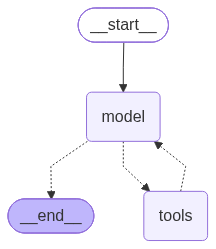

In [8]:
from IPython.display import Image, display

# Affiche le graphe interne de l'agent (boucle ReAct)
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

## 9. Interroger l'agent

### Objectif

Poser des questions en langage naturel à l'agent.

### Méthode

- `agent.stream()` exécute l'agent et retourne les messages **un par un**
- `stream_mode="values"` retourne l'état complet après chaque étape
- `context=RuntimeContext(db=db)` transmet la connexion BDD à l'agent

### Résultat attendu

Vous verrez la question, les appels SQL intermédiaires et la réponse finale.

### Si vous obtenez un erreur serveur sur votre appel

- 401 "Wrong API endpoint" → le client tape sur api.mistral.ai public au lieu du serveur dédié.
- 404 "Route Not Found" → l'URL manquait le préfixe /v1.
- 400 "Invalid model" → mistral-large-latest n'est pas déployé sur cette instance.
- 403 "Forbidden" (dans l'output) → clé LangChain invalide.

> La traçabilité LangSmith n'est **pas nécessaire** pour la formation. Sans clé valide, gardez `LANGSMITH_TRACING=false` dans le `.env`.
>
> Si `=true` avec une clé absente/invalide, une erreur **403 Forbidden** (`.../runs/multipart`) apparaîtra pendant l'exécution. Elle est **sans impact sur l'agent** — pour la faire disparaître, passez à `false` puis redémarrez le kernel.

In [9]:
question = "Quelle table possède le plus grand nombre d'entrées ?"

# agent.stream() exécute l'agent et diffuse les étapes une par une.
# À chaque étape, on affiche le dernier message (question, appel outil, réponse).
for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Quelle table possède le plus grand nombre d'entrées ?
================================== Ai Message ==================================

Pour déterminer quelle table possède le plus grand nombre d'entrées, je vais suivre ces étapes :

1. **Lister toutes les tables** de la base de données.
2. **Compter le nombre d'entrées** pour chaque table.
3. **Identifier la table avec le plus grand nombre d'entrées**.

Je commence par lister toutes les tables disponibles dans la base de données.
Tool Calls:
  execute_sql (p3X5ZddSi)
 Call ID: p3X5ZddSi
  Args:
    query: SELECT name FROM sqlite_master WHERE type = 'table';
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai M

In [10]:
question = "Quel genre musical possède en moyenne les pistes les plus longues ?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Quel genre musical possède en moyenne les pistes les plus longues ?
================================== Ai Message ==================================

Pour répondre à cette question, je vais suivre ces étapes :

1. **Identifier les tables pertinentes** : Je dois trouver les tables qui contiennent les informations sur les **genres musicaux** et les **pistes** (ou morceaux), ainsi que leur durée.
2. **Comprendre les relations** : Vérifier comment les genres sont associés aux pistes (par exemple, via une table de jointure ou une clé étrangère).
3. **Calculer la durée moyenne** : Pour chaque genre, calculer la durée moyenne de ses pistes.
4. **Trouver le genre avec la durée moyenne la plus élevée** : Comparer les résultats et identifier le genre avec la durée moyenne maximale.

### Étape 1 : Explorer les tables disponibles
Je vais d'abord lister les tables de la base de données pour comprendre sa structure.
To

In [14]:
from IPython.display import Markdown, display

question = "Liste tous les artistes dont le nom commence par 'A'."

dernier_message = None
for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    dernier_message_stream = step["messages"][-1].pretty_print()
    dernier_message = step["messages"][-1]

# Rendu Markdown de la réponse finale
display(Markdown(dernier_message.content))

================================ Human Message =================================

Liste tous les artistes dont le nom commence par 'A'.
================================== Ai Message ==================================
Tool Calls:
  execute_sql (T3IuQjlmI)
 Call ID: T3IuQjlmI
  Args:
    query: SELECT name FROM artists WHERE name LIKE 'A%' ORDER BY name LIMIT 5;
================================= Tool Message =================================
Name: execute_sql

Error: (sqlite3.OperationalError) no such table: artists
[SQL: SELECT name FROM artists WHERE name LIKE 'A%' ORDER BY name LIMIT 5;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)
================================== Ai Message ==================================
Tool Calls:
  execute_sql (q5FGmA1aE)
 Call ID: q5FGmA1aE
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table';
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Custom

Voici les 5 premiers artistes dont le nom commence par **"A"** dans la base de données :

1. A Cor Do Som
2. AC/DC
3. Aaron Copland & London Symphony Orchestra
4. Aaron Goldberg
5. Academy of St. Martin in the Fields & Sir Neville Marriner

Si tu veux voir davantage de résultats, fais-le-moi savoir !

### 🎯 À vous de jouer !

Remplacez la question ci-dessous par votre propre requête en langage naturel.

In [ ]:
question = "POSEZ VOTRE PROPRE QUESTION ICI"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

## Ce qu'il faut retenir

- Un **agent IA** est un programme qui décide quelle action effectuer pour répondre à une question.
- `create_agent` de LangChain assemble le modèle, les outils et les instructions en une seule ligne.
- Le décorateur `@tool` transforme une fonction Python en outil que le modèle Mistral peut appeler.
- Le modèle **décide** d'appeler l'outil ; le code Python **exécute** réellement l'action.
- La boucle agentique (ReAct) continue jusqu'à ce que l'agent ait une réponse satisfaisante.

---

> **Prochaine étape →** Dans **L2**, nous allons explorer en détail les **messages** qui circulent
> entre l'utilisateur, le modèle et les outils. C'est la fondation de toute application LangChain.

## Documentation officielle

**LangChain**
- [Agents (create_agent)](https://docs.langchain.com/oss/python/langchain/agents)
- [Tools (décorateur @tool)](https://docs.langchain.com/oss/python/langchain/tools)
- [Streaming (agent.stream)](https://docs.langchain.com/oss/python/langchain/streaming)
- [Messages (System/Human/AI/Tool)](https://docs.langchain.com/oss/python/langchain/messages) — approfondi en L2

**Mistral AI**
- [ChatMistralAI (intégration LangChain)](https://docs.langchain.com/oss/python/integrations/chat/mistralai)
- [Modèles disponibles](https://docs.mistral.ai/getting-started/models/models_overview/)
- [Référence API Mistral](https://docs.mistral.ai/api/)